# RetailHub — Data Analysis, Cleaning & Exploratory Data Analysis
**Week 1 Assignment — Data Analytics Internship**

This notebook cleans and analyzes RetailHub's customer, product, order, payment, and
category datasets, and answers the business questions listed in the task brief.
All file paths are relative to this notebook's folder (`Week1_Assignment/`).

In [91]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

RAW = 'datasets/'
OUT = 'output/'
os.makedirs(OUT, exist_ok=True)

## Part 1 — Importing Data
Import all five datasets (CSV, Excel, JSON) into Pandas DataFrames and preview them.

In [92]:
customers = pd.read_csv(r"C:\Users\User\Downloads\customers.csv")
orders = pd.read_csv(r"C:\Users\User\Downloads\orders.csv")
products = pd.read_csv(r"C:\Users\User\Downloads\products (18) (1).csv")
payments = pd.read_excel(r"C:\Users\User\Downloads\payments.xlsx")
categories = pd.read_json(r"C:\Users\User\Downloads\categories (3).json")

print("customers:", customers.shape)
print("orders:", orders.shape)
print("products:", products.shape)
print("payments:", payments.shape)
print("categories:", categories.shape)

customers: (139, 8)
orders: (146, 8)
products: (141, 6)
payments: (150, 6)
categories: (163, 4)


In [93]:
customers.head()

,customer_id,name,email,phone,gender,city,age,registration_date
0,1,Customer 1,customer1@example.com,3.244273e+09,Male,Islamabad,25,2024-01-02
1,2,Customer 2,customer2@example.com,3.631969e+09,Female,Faisalabad,59,2024-01-03
2,3,Customer 3,customer3@example.com,3.507609e+09,Male,Lahore,49,2024-01-04
3,4,Customer 4,customer4@example.com,3.130438e+09,Female,Faisalabad,56,2024-01-05
4,5,Customer 5,customer5@example.com,3.918492e+09,Male,Faisalabad,35,2024-01-06


In [94]:
orders.head()

,order_id,customer_id,product_id,quantity,discount,order_date,status,amount
0,1,6.0,6.0,4.0,10,2025-01-02,Pending,111096.0
1,2,3.0,25.0,3.0,10,2025-01-03,Pending,47739.0
2,3,20.0,21.0,5.0,5,2025-01-04,Completed,30245.0
3,4,40.0,7.0,5.0,0,2025-01-05,Pending,5275.0
4,5,16.0,15.0,1.0,15,2025-01-06,Pending,26866.0


In [95]:
products.head()

,product_id,product_name,category_id,brand,price,stock
0,1,Product 1,42.0,Samsung,26380.0,177.0
1,2,Product 2,37.0,Apple,43742.0,166.0
2,3,Product 3,28.0,Samsung,48829.0,81.0
3,4,Product 4,9.0,Nike,3609.0,83.0
4,5,Product 5,5.0,Samsung,20839.0,81.0


In [96]:
payments.head()

,payment_id,order_id,payment_method,amount,payment_status,transaction_id
0,1,1.0,JazzCash,111096.0,Pending,TXN00001
1,2,2.0,Bank Transfer,47739.0,Failed,TXN00002
2,3,3.0,JazzCash,30245.0,Failed,TXN00003
3,4,4.0,JazzCash,5275.0,Paid,TXN00004
4,5,5.0,Cash,26866.0,Pending,TXN00005


In [97]:
categories.head()

,category_id,category_name,parent_category,description
0,1,Electronics,General,Electronics products
1,2,Clothing,General,Clothing products
2,3,Home,General,Home products
3,4,Sports,General,Sports products
4,5,Books,General,Books products


## Part 2 — Exploratory Data Analysis (EDA)
For every dataset we inspect shape, columns, dtypes, descriptive stats, missing values,
and unique value counts for key columns.

In [98]:
def explore(name, df):#
    print("Shape:", df.shape)
    print("\nColumns:", list(df.columns))
    print("\nDtypes:\n", df.dtypes)
    #first 10 rows of df
    print("\nFirst 10 rows:")
    display(df.head(10))
    print("\nLast 10 rows:")
    display(df.tail(10))
    print("\nDescriptive statistics:")
    display(df.describe(include='all').T)#
    print("\nMissing values per column:\n", df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())

for name, df in [('customers', customers), ('orders', orders), ('products', products),
                  ('payments', payments), ('categories', categories)]:
    explore(name, df)

Shape: (139, 8)

Columns: ['customer_id', 'name', 'email', 'phone', 'gender', 'city', 'age', 'registration_date']

Dtypes:
 customer_id            int64
name                     str
email                    str
phone                float64
gender                   str
city                     str
age                      str
registration_date        str
dtype: object

First 10 rows:


,customer_id,name,email,phone,gender,city,age,registration_date
0,1,Customer 1,customer1@example.com,3.244273e+09,Male,Islamabad,25,2024-01-02
1,2,Customer 2,customer2@example.com,3.631969e+09,Female,Faisalabad,59,2024-01-03
2,3,Customer 3,customer3@example.com,3.507609e+09,Male,Lahore,49,2024-01-04
3,4,Customer 4,customer4@example.com,3.130438e+09,Female,Faisalabad,56,2024-01-05
4,5,Customer 5,customer5@example.com,3.918492e+09,Male,Faisalabad,35,2024-01-06
5,6,Customer 6,customer6@example.com,3.874748e+09,Male,Rawalpindi,24,2024-01-07
6,7,Customer 7,customer7@example.com,3.440837e+09,Male,Lahore,19,2024-01-08
7,8,Customer 8,customer8@example.com,3.797445e+09,Male,Faisalabad,31,2024-01-09
8,9,Customer 9,customer9@example.com,3.553244e+09,Male,Rawalpindi,32,2024-01-10
9,10,Customer 10,customer10@example.com,3.920018e+09,Female,Faisalabad,53,2024-01-11



Last 10 rows:


,customer_id,name,email,phone,gender,city,age,registration_date
129,130,Customer 130,customer130@example.com,3.809129e+09,Male,lahore,NaN,2024-03-01
130,27,Customer 27,customer27@example.com,3.469180e+09,Female,Faisalabad,35,2024-01-28
131,29,Customer 29,customer29@example.com,3.968807e+09,Male,Rawalpindi,53,2024-01-30
132,45,Customer 45,customer45@example.com,3.954916e+09,Male,Islamabad,24,2024-02-15
133,39,Customer 39,customer39@example.com,3.217563e+09,Male,Islamabad,36,2024-02-09
134,31,Customer 31,customer31@example.com,3.491632e+09,Male,Rawalpindi,44,2024-02-01
135,19,Customer 19,customer19@example.com,3.813763e+09,Male,Islamabad,53,2024-01-20
136,3,Customer 3,customer3@example.com,3.507609e+09,Male,Lahore,49,2024-01-04
137,15,Customer 15,customer15@example.com,3.874688e+09,Female,Rawalpindi,60,2024-01-16
138,3,Customer 3,CUSTOMER3@example.com,3.507609e+09,Male,Lahore,49,2024-01-04



Descriptive statistics:


...


Last 10 rows:


,category_id,category_name,parent_category,description
153,154,category 154,Misc,Misc
154,2,Clothing,General,Clothing products
155,49,Category 49,General,Misc
156,9,Category 9,General,Misc
157,20,Category 20,General,Misc
158,19,Category 19,General,Misc
159,35,Category 35,General,Misc
160,22,Category 22,General,Misc
161,40,Category 40,General,Misc
162,2,clothing,General,NaN



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
category_id,163.0,NaN,NaN,NaN,74.435583,45.320401,1.0,35.0,73.0,113.5,154.0
category_name,162,123,Electronics,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_category,153,5,General,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,141,9,Misc,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values per column:
 category_id         0
category_name       1
parent_category    10
description        22
dtype: int64

Duplicate rows: 8


**Answers — EDA Questions**
1. Record counts (raw): customers=139, orders=146, products=141, payments=150, categories=163.
2. Columns with missing values: nearly every column in every file (see missing-value counts above) —
   e.g. `email`, `phone`, `gender`, `city`, `age`, `registration_date` in customers;
   `customer_id`, `product_id`, `quantity`, `discount`, `order_date`, `status`, `amount` in orders;
   `category_id`, `brand`, `price`, `stock` in products; `order_id`, `payment_method`, `amount`,
   `payment_status`, `transaction_id` in payments; `category_name`, `parent_category`, `description` in categories.
3. Categorical columns: `gender`, `city`, `status`, `discount` (label-like), `brand`, `category_name`,
   `parent_category`, `payment_method`, `payment_status`.
4. Numerical columns: `customer_id`, `age`, `phone`, `order_id`, `product_id`, `quantity`, `amount`,
   `price`, `stock`, `category_id`, `payment_id`.

## Part 3 — Data Cleaning
Every dataset is cleaned in the same disciplined sequence:
1. Lower-case & snake_case all column names.
2. Strip extra whitespace from every text column.
3. Remove exact duplicate rows, then duplicate primary keys.
4. Standardize inconsistent text formatting (casing, spelling variants).
5. Convert columns to correct dtypes (numeric, datetime).
6. Detect and fix **negative / zero / invalid** values (treated as missing, then imputed).
7. Fill missing values using the median (numeric) or a sensible category (text), documented inline.

In [99]:
def lower_cols(df):
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    return df

def strip_str_cols(df):
    for c in df.select_dtypes(include='object',exclude='string').columns:
        df[c] = df[c].astype(str).str.strip()
        df[c] = df[c].replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    return df

for df in [customers, orders, products, payments, categories]:
    lower_cols(df)
    strip_str_cols(df)

report = {'duplicates_removed': {}, 'missing_before': {}, 'missing_after': {}}
for name, df in [('customers', customers), ('orders', orders), ('products', products),
                  ('payments', payments), ('categories', categories)]:
    report['missing_before'][name] = int(df.isnull().sum().sum())

### 3.1 Clean `customers`

In [100]:
dup = customers.duplicated().sum()
customers = customers.drop_duplicates()                       # remove exact duplicate rows
dup_id = customers.duplicated(subset='customer_id').sum()
customers = customers.drop_duplicates(subset='customer_id', keep='first')  # duplicate customer IDs
report['duplicates_removed']['customers'] = int(dup + dup_id)

# Gender: collapse M/F/male/female variants -> Male/Female ; unmapped -> Unknown
gender_map = {'m': 'Male', 'male': 'Male', 'f': 'Female', 'female': 'Female'}
customers['gender'] = customers['gender'].str.lower().map(gender_map).fillna('Unknown')

# City: strip + title-case so 'LAHORE ', ' Lahore', 'lahore' all become 'Lahore'
customers['city'] = customers['city'].str.strip().str.title().fillna('Unknown')

# Age: coerce to numeric; negative ages (-5) and 'unknown' text are invalid -> NaN -> filled with median
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')
customers.loc[customers['age'] < 0, 'age'] = np.nan
median_age = customers['age'].median()
customers['age'] = customers['age'].fillna(median_age).astype(int)

# Email: missing -> placeholder, lower-cased for consistency
customers['email'] = customers['email'].fillna('unknown@example.com').str.lower()

# Phone: numeric, missing -> 'Unknown' (kept as text since not used in math)
customers['phone'] = pd.to_numeric(customers['phone'], errors='coerce')
customers['phone'] = customers['phone'].apply(lambda x: str(int(x)) if pd.notnull(x) else 'Unknown')

# Registration date: convert to datetime; missing -> filled with the most frequent date (mode)
customers['registration_date'] = pd.to_datetime(customers['registration_date'], errors='coerce')
customers['registration_date'] = customers['registration_date'].fillna(customers['registration_date'].mode()[0])

# Name: title case, whitespace already stripped
customers['name'] = customers['name'].str.strip().str.title()
customers = customers.reset_index(drop=True)
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        130 non-null    int64         
 1   name               130 non-null    str           
 2   email              130 non-null    str           
 3   phone              130 non-null    str           
 4   gender             130 non-null    str           
 5   city               130 non-null    str           
 6   age                130 non-null    int64         
 7   registration_date  130 non-null    datetime64[us]
dtypes: datetime64[us](1), int64(2), str(5)
memory usage: 8.3 KB


### 3.2 Clean `products`

In [101]:
dup = products.duplicated().sum()
products = products.drop_duplicates()
dup_id = products.duplicated(subset='product_id').sum()
products = products.drop_duplicates(subset='product_id', keep='first')
report['duplicates_removed']['products'] = int(dup + dup_id)

products['product_name'] = products['product_name'].str.strip().str.title()

# Brand: standardize casing (samsung/APPLE -> Samsung/Apple); missing -> Generic
products['brand'] = products['brand'].str.strip().str.title().fillna('Generic')

# Price: negative or zero prices are invalid -> NaN -> filled with the median price for that brand
products['price'] = pd.to_numeric(products['price'], errors='coerce')
products.loc[products['price'] <= 0, 'price'] = np.nan
overall_median_price = products['price'].median()
products['price'] = products.groupby('brand')['price'].transform(lambda s: s.fillna(s.median()))
products['price'] = products['price'].fillna(overall_median_price).round(2)

# Stock: negative stock is physically impossible -> set to 0; missing -> median stock
products['stock'] = pd.to_numeric(products['stock'], errors='coerce')
products.loc[products['stock'] < 0, 'stock'] = 0
products['stock'] = products['stock'].fillna(products['stock'].median()).astype(int)

# category_id: keep as numeric; missing handled after merging with categories (mapped to 'Unknown Category')
products['category_id'] = pd.to_numeric(products['category_id'], errors='coerce')
products = products.reset_index(drop=True)
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    134 non-null    int64  
 1   product_name  134 non-null    str    
 2   category_id   108 non-null    float64
 3   brand         134 non-null    str    
 4   price         134 non-null    float64
 5   stock         134 non-null    int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 6.4 KB


### 3.3 Clean `categories`

In [102]:
dup = categories.duplicated().sum()
categories = categories.drop_duplicates()
dup_id = categories.duplicated(subset='category_id').sum()
categories = categories.drop_duplicates(subset='category_id', keep='first')
report['duplicates_removed']['categories'] = int(dup + dup_id)

categories['category_name'] = categories['category_name'].str.strip().str.title().fillna('Unknown Category')
categories['parent_category'] = categories['parent_category'].str.strip().str.title().fillna('General')
categories['description'] = categories['description'].fillna('No description available')
categories = categories.reset_index(drop=True)

# Add a placeholder category for products whose category_id was missing
if 0 not in categories['category_id'].values:
    categories = pd.concat([categories, pd.DataFrame([{
        'category_id': 0, 'category_name': 'Unknown Category',
        'parent_category': 'General', 'description': 'No description available'}])], ignore_index=True)
products['category_id'] = products['category_id'].fillna(0).astype(int)
categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   category_id      155 non-null    int64
 1   category_name    155 non-null    str  
 2   parent_category  155 non-null    str  
 3   description      155 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.0 KB


### 3.4 Clean `orders`

In [103]:
dup = orders.duplicated().sum()
orders = orders.drop_duplicates()
report['duplicates_removed']['orders'] = int(dup)

valid_customer_ids = set(customers['customer_id'])
valid_product_ids = set(products['product_id'])
orders['customer_id'] = pd.to_numeric(orders['customer_id'], errors='coerce')
orders['product_id'] = pd.to_numeric(orders['product_id'], errors='coerce')

# Sentinel / impossible foreign keys (e.g. 9999, 8888) don't exist in the master tables -> invalid -> NaN
orders.loc[~orders['customer_id'].isin(valid_customer_ids), 'customer_id'] = np.nan
orders.loc[~orders['product_id'].isin(valid_product_ids), 'product_id'] = np.nan

rows_before = len(orders)
orders = orders.dropna(subset=['customer_id', 'product_id']).reset_index(drop=True)  # can't keep an order with no valid customer/product
report['orders_dropped_invalid_fk'] = int(rows_before - len(orders))
orders['customer_id'] = orders['customer_id'].astype(int)
orders['product_id'] = orders['product_id'].astype(int)

# Quantity: zero/negative quantity is invalid -> NaN -> filled with median quantity
orders['quantity'] = pd.to_numeric(orders['quantity'], errors='coerce')
orders.loc[orders['quantity'] <= 0, 'quantity'] = np.nan
orders['quantity'] = orders['quantity'].fillna(orders['quantity'].median()).astype(int)

# Discount: strip '%' sign, convert to numeric percent, missing -> 0, clip to sane 0-100 range
orders['discount'] = orders['discount'].astype(str).str.replace('%', '', regex=False)
orders['discount'] = pd.to_numeric(orders['discount'], errors='coerce').fillna(0).clip(lower=0, upper=100)

# Order date: convert to datetime; missing -> filled with median order date
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
orders['order_date'] = orders['order_date'].fillna(orders['order_date'].median())

# Status: standardize casing; missing -> Unknown
orders['status'] = orders['status'].str.strip().str.title().fillna('Unknown')

# Amount: negative amounts are invalid -> NaN (recomputed below from product price)
orders['amount'] = pd.to_numeric(orders['amount'], errors='coerce')
orders.loc[orders['amount'] < 0, 'amount'] = np.nan
orders = orders.reset_index(drop=True)
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     133 non-null    int64         
 1   customer_id  133 non-null    int64         
 2   product_id   133 non-null    int64         
 3   quantity     133 non-null    int64         
 4   discount     133 non-null    float64       
 5   order_date   133 non-null    datetime64[us]
 6   status       133 non-null    str           
 7   amount       73 non-null     float64       
dtypes: datetime64[us](1), float64(2), int64(4), str(1)
memory usage: 8.4 KB


### 3.5 Clean `payments`

In [104]:
dup = payments.duplicated().sum()
payments = payments.drop_duplicates()
report['duplicates_removed']['payments'] = int(dup)

payments['order_id'] = pd.to_numeric(payments['order_id'], errors='coerce')
rows_before = len(payments)
payments = payments.dropna(subset=['order_id']).reset_index(drop=True)  # a payment with no order reference is unusable
report['payments_dropped_missing_orderid'] = int(rows_before - len(payments))
payments['order_id'] = payments['order_id'].astype(int)

# Payment method: collapse case/spelling variants (jazzcash, CASH, Credit Card -> JazzCash, Cash, Card)
pm_map = {'jazzcash': 'JazzCash', 'easypaisa': 'EasyPaisa', 'cash': 'Cash',
          'card': 'Card', 'credit card': 'Card', 'bank transfer': 'Bank Transfer'}
payments['payment_method'] = payments['payment_method'].str.strip().str.lower().map(pm_map).fillna('Unknown')

# Payment status: standardize casing
ps_map = {'pending': 'Pending', 'failed': 'Failed', 'paid': 'Paid'}
payments['payment_status'] = payments['payment_status'].str.strip().str.lower().map(ps_map).fillna('Unknown')

# Amount: negative payment amounts are invalid -> NaN -> filled with median
payments['amount'] = pd.to_numeric(payments['amount'], errors='coerce')
payments.loc[payments['amount'] < 0, 'amount'] = np.nan
payments['amount'] = payments['amount'].fillna(payments['amount'].median()).round(2)

payments['transaction_id'] = payments['transaction_id'].fillna('UNKNOWN')
payments = payments.reset_index(drop=True)
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   payment_id      143 non-null    int64  
 1   order_id        143 non-null    int64  
 2   payment_method  143 non-null    str    
 3   amount          143 non-null    float64
 4   payment_status  143 non-null    str    
 5   transaction_id  143 non-null    str    
dtypes: float64(1), int64(2), str(3)
memory usage: 6.8 KB


In [105]:
# Recompute order amount from product price wherever the original amount was missing/invalid
prod_price_map = products.set_index('product_id')['price'].to_dict()

def compute_amount(row):
    if pd.isnull(row['amount']):
        price = prod_price_map.get(row['product_id'], overall_median_price)
        return round(price * row['quantity'] * (1 - row['discount'] / 100), 2)
    return row['amount']

orders['amount'] = orders.apply(compute_amount, axis=1)

for name, df in [('customers', customers), ('orders', orders), ('products', products),
                  ('payments', payments), ('categories', categories)]:
    report['missing_after'][name] = int(df.isnull().sum().sum())

print("Duplicates removed per dataset:", report['duplicates_removed'])
print("Missing values before cleaning:", report['missing_before'])
print("Missing values after cleaning :", report['missing_after'])
print("Orders dropped (invalid foreign keys):", report['orders_dropped_invalid_fk'])
print("Payments dropped (missing order_id):", report['payments_dropped_missing_orderid'])

Duplicates removed per dataset: {'customers': 9, 'products': 7, 'categories': 9, 'orders': 7, 'payments': 6}
Missing values before cleaning: {'customers': 64, 'orders': 95, 'products': 113, 'payments': 67, 'categories': 33}
Missing values after cleaning : {'customers': 0, 'orders': 0, 'products': 0, 'payments': 0, 'categories': 0}
Orders dropped (invalid foreign keys): 6
Payments dropped (missing order_id): 1


## Part 4 — Working with DataFrames
Filtering, sorting, and `loc`/`iloc` indexing examples.

In [106]:
# Filtering
customers_lahore = customers[customers['city'] == 'Lahore']
orders_above_50k = orders[orders['amount'] > 50000]
products_electronics = products.merge(categories, on='category_id')[
    lambda d: d['category_name'] == 'Electronics']
pending_payments = payments[payments['payment_status'] == 'Pending']

print("Customers from Lahore:", len(customers_lahore))
display(customers_lahore)
print("Orders above 50,000:", len(orders_above_50k))
display(orders_above_50k)
print("Electronics products:", len(products_electronics))
display(products_electronics)
print("Pending payments:", len(pending_payments))
display(pending_payments)

Customers from Lahore: 32


,customer_id,name,email,phone,gender,city,age,registration_date
2,3,Customer 3,customer3@example.com,3507608741,Male,Lahore,49,2024-01-04
6,7,Customer 7,customer7@example.com,3440837476,Male,Lahore,19,2024-01-08
13,14,Customer 14,customer14@example.com,3877001467,Female,Lahore,39,2024-01-15
19,20,Customer 20,customer20@example.com,3854884265,Female,Lahore,46,2024-01-21
24,25,Customer 25,customer25@example.com,3639274549,Male,Lahore,30,2024-01-26
29,30,Customer 30,customer30@example.com,3320638116,Female,Lahore,48,2024-01-31
34,35,Customer 35,customer35@example.com,3727560084,Male,Lahore,53,2024-02-05
35,36,Customer 36,customer36@example.com,3955876987,Female,Lahore,22,2024-02-06
42,43,Customer 43,customer43@example.com,3633106007,Female,Lahore,19,2024-02-13
47,48,Customer 48,customer48@example.com,3526614131,Male,Lahore,28,2024-02-18


Orders above 50,000: 64


,order_id,customer_id,product_id,quantity,discount,order_date,status,amount
0,1,6,6,4,10.0,2025-01-02,Pending,111096.00
5,6,5,18,5,0.0,2025-01-07,Pending,223505.00
7,8,7,31,2,10.0,2025-01-09,Pending,75182.00
8,9,12,33,2,5.0,2025-01-10,Pending,61000.00
10,11,35,14,2,0.0,2025-01-12,Completed,66508.00
...,...,...,...,...,...,...,...,...
121,128,35,20,3,0.0,2025-04-15,Pending,106197.00
126,133,113,72,3,10.0,2025-04-13,Shipped,135809.00
127,134,22,93,3,10.0,2025-10-13,Unknown,62651.34
129,136,6,57,5,0.0,2025-05-01,Shipped,111320.00


Electronics products: 2


,product_id,product_name,category_id,brand,price,stock,category_name,parent_category,description
42,43,Product 43,1,Apple,48110.0,157,Electronics,General,Electronics products
68,69,Product 69,1,Apple,21287.5,0,Electronics,General,Electronics products


Pending payments: 37


,payment_id,order_id,payment_method,amount,payment_status,transaction_id
0,1,1,JazzCash,111096.0,Pending,TXN00001
4,5,5,Cash,26866.0,Pending,TXN00005
5,6,6,EasyPaisa,223505.0,Pending,TXN00006
7,8,8,EasyPaisa,75182.0,Pending,TXN00008
8,9,9,Bank Transfer,61000.0,Pending,TXN00009
10,11,11,EasyPaisa,66508.0,Pending,TXN00011
12,13,13,Cash,141596.0,Pending,TXN00013
16,17,17,Bank Transfer,71544.0,Pending,TXN00017
18,19,19,Card,14118.0,Pending,TXN00019
24,25,25,EasyPaisa,31192.0,Pending,TXN00025


In [107]:
# Sorting
customers_by_name = customers.sort_values('name')# Sort by name
products_by_price = products.sort_values('price')# Sort by price
orders_by_date = orders.sort_values('order_date')# Sort by order date
highest_value_orders = orders.sort_values('amount', ascending=False)# Sort by amount
highest_value_orders.head()# Show top 5

,order_id,customer_id,product_id,quantity,discount,order_date,status,amount
5,6,5,18,5,0.0,2025-01-07,Pending,223505.0
81,84,95,20,6,5.0,2025-05-06,Shipped,201774.3
11,12,48,40,5,5.0,2025-01-13,Pending,182790.0
27,28,24,20,5,5.0,2025-01-29,Cancelled,176995.0
44,45,49,20,5,10.0,2025-02-15,Cancelled,176995.0


In [108]:
# Indexing with loc / iloc
print("loc - specific rows & columns:")
display(customers.loc[0:4, ['customer_id', 'name', 'city']])

print("iloc - row range & specific columns:")
display(customers.iloc[0:5, 0:3])

print("Conditional selection with loc:")
display(orders.loc[orders['status'] == 'Completed', ['order_id', 'amount', 'status']].head())

loc - specific rows & columns:


,customer_id,name,city
0,1,Customer 1,Islamabad
1,2,Customer 2,Faisalabad
2,3,Customer 3,Lahore
3,4,Customer 4,Faisalabad
4,5,Customer 5,Faisalabad


iloc - row range & specific columns:


,customer_id,name,email
0,1,Customer 1,customer1@example.com
1,2,Customer 2,customer2@example.com
2,3,Customer 3,customer3@example.com
3,4,Customer 4,customer4@example.com
4,5,Customer 5,customer5@example.com


Conditional selection with loc:


,order_id,amount,status
2,3,30245.0,Completed
6,7,21108.0,Completed
10,11,66508.0,Completed
15,16,40080.0,Completed
19,20,93276.0,Completed


## Part 5 — GroupBy and Aggregation

In [109]:
# Merging on product id
revenue_by_category = orders.merge(products, on='product_id').merge(
    categories, on='category_id')['amount' if False else 'category_name']  # placeholder guard
# Proper aggregation below uses the merged sales table built in Part 6, computed here for a quick check
orders_products = orders.merge(products, on='product_id')
print("Total revenue by category (pre-merge check):")
display(orders_products.merge(categories, on='category_id').groupby('category_name')['amount'].sum().sort_values(ascending=False).head())

Total revenue by category (pre-merge check):


category_name
Category 35         1251619.75
Unknown Category     893557.83
Category 11          477898.00
Books                365069.43
Category 99          322353.10
Name: amount, dtype: float64

In [110]:
# Merging on customer id
orders_customers = orders.merge(customers, on='customer_id')
print("Total revenue by city:")
display(orders_customers.groupby('city')['amount'].sum().sort_values(ascending=False))
# Merging on order id
print("\nNumber of customers per city:")
display(customers.groupby('city')['customer_id'].nunique().sort_values(ascending=False))
#number of orders per customer
print("\nNumber of orders per customer:")
display(orders.groupby('customer_id')['order_id'].count().sort_values(ascending=False).head())
# Average order value
print("\nAverage order value:", round(orders['amount'].mean(), 2))
# Highest-selling products
print("\nHighest-selling products (by quantity):")
display(orders.groupby('product_id')['quantity'].sum().sort_values(ascending=False).head())
# Monthly revenue
print("\nMonthly revenue:")
display(orders.assign(month=orders['order_date'].dt.to_period('M')).groupby('month')['amount'].sum())
# Payment method distribution
print("\nPayment method distribution:")
display(payments['payment_method'].value_counts())
# Multiple aggregations
print("\nMultiple aggregations on amount:")
display(orders['amount'].agg(['sum', 'mean', 'count', 'min', 'max', 'median']))

Total revenue by city:


city
Lahore        2089506.39
Karachi       1459322.71
Faisalabad    1310632.46
Rawalpindi    1211528.48
Islamabad      625814.52
Sialkot        301168.61
Multan         205094.69
Peshawar       185297.66
Quetta         171227.00
Unknown        142385.00
Name: amount, dtype: float64


Number of customers per city:


city
Lahore        32
Karachi       23
Rawalpindi    18
Faisalabad    17
Islamabad     12
Multan         8
Quetta         6
Peshawar       5
Sialkot        5
Unknown        4
Name: customer_id, dtype: int64


Number of orders per customer:


...

month
2025-01    2095453.38
2025-02    1837574.94
2025-03     267569.66
2025-04     490080.09
2025-05     511878.85
2025-06     243473.87
2025-07     351599.68
2025-08     351733.06
2025-09     559428.26
2025-10     566543.24
2025-11     277899.27
2025-12     148743.22
Freq: M, Name: amount, dtype: float64


Payment method distribution:


payment_method
Cash             36
JazzCash         32
Bank Transfer    26
Card             24
EasyPaisa        15
Unknown          10
Name: count, dtype: int64


Multiple aggregations on amount:


sum       7.701978e+06
mean      5.790961e+04
count     1.330000e+02
min       6.420000e+02
max       2.235050e+05
median    4.773900e+04
Name: amount, dtype: float64

## Part 6 — Merging Multiple Datasets
Build one complete sales dataset: `customers + orders + products + payments + categories`.

In [111]:
# categories + products
products_full = products.merge(categories, on='category_id', how='left')

# orders + products_full
orders_products = orders.merge(products_full, on='product_id', how='left', suffixes=('_order', '_product'))

# + customers
merged = orders_products.merge(customers, on='customer_id', how='left', suffixes=('', '_customer'))

# + payments (dedup: keep the latest payment record per order)
payments_dedup = payments.drop_duplicates(subset='order_id', keep='last')
merged = merged.merge(payments_dedup, on='order_id', how='left', suffixes=('_order', '_payment'))

print("Merged shape:", merged.shape)
print("Orders missing customer info after merge:", merged['name'].isnull().sum())
print("Orders missing product info after merge:", merged['product_name'].isnull().sum())
print("Orders missing payment info after merge (no payment record at all):", merged['payment_id'].isnull().sum())
merged.head()

Merged shape: (133, 28)
Orders missing customer info after merge: 0
Orders missing product info after merge: 0
Orders missing payment info after merge (no payment record at all): 45


,order_id,customer_id,product_id,quantity,discount,order_date,status,amount_order,product_name,category_id,brand,price,stock,category_name,parent_category,description,name,email,phone,gender,city,age,registration_date,payment_id,payment_method,amount_payment,payment_status,transaction_id
0,1,6,6,4,10.0,2025-01-02,Pending,111096.0,Product 6,48,Nike,27774.0,149,Category 48,General,Misc,Customer 6,customer6@example.com,3874747711,Male,Rawalpindi,24,2024-01-07,1.0,JazzCash,111096.0,Pending,TXN00001
1,2,3,25,3,10.0,2025-01-03,Pending,47739.0,Product 25,8,Apple,15913.0,159,Category 8,General,Misc,Customer 3,customer3@example.com,3507608741,Male,Lahore,49,2024-01-04,2.0,Bank Transfer,47739.0,Failed,TXN00002
2,3,20,21,5,5.0,2025-01-04,Completed,30245.0,Product 21,5,Samsung,6049.0,39,Books,General,Books products,Customer 20,customer20@example.com,3854884265,Female,Lahore,46,2024-01-21,71.0,Cash,83042.0,Paid,TXN00071
3,4,40,7,5,0.0,2025-01-05,Pending,5275.0,Product 7,17,Nike,1055.0,148,Category 17,General,Misc,Customer 40,customer40@example.com,3174641570,Male,Karachi,34,2024-02-10,4.0,JazzCash,5275.0,Paid,TXN00004
4,5,16,15,1,15.0,2025-01-06,Pending,26866.0,Product 15,21,Sony,26866.0,77,Category 21,General,Misc,Customer 16,customer16@example.com,3303849597,Female,Islamabad,55,2024-01-17,5.0,Cash,26866.0,Pending,TXN00005


## Part 7 — Data Transformation
New columns, `apply`/`lambda`/`map`, and reshaping with `pivot_table` / `melt`.

In [112]:
merged['total_price'] = merged['price'] * merged['quantity']
merged['discount_amount'] = (merged['total_price'] * merged['discount'] / 100).round(2)
merged['net_revenue'] = (merged['total_price'] - merged['discount_amount']).round(2)
merged['order_month'] = merged['order_date'].dt.to_period('M').astype(str)

# apply() + lambda
merged['price_tier'] = merged['price'].apply(lambda x: 'High' if x > 30000 else ('Medium' if x > 10000 else 'Low'))

# map()
status_flag_map = {'Completed': 'Closed', 'Shipped': 'Closed', 'Pending': 'Open', 'Cancelled': 'Closed', 'Unknown': 'Open'}
merged['order_flag'] = merged['status'].map(status_flag_map).fillna('Open')

merged[['order_id', 'total_price', 'discount_amount', 'net_revenue', 'order_month', 'price_tier', 'order_flag']].head()

,order_id,total_price,discount_amount,net_revenue,order_month,price_tier,order_flag
0,1,111096.0,11109.60,99986.40,2025-01,Medium,Open
1,2,47739.0,4773.90,42965.10,2025-01,Medium,Open
2,3,30245.0,1512.25,28732.75,2025-01,Low,Closed
3,4,5275.0,0.00,5275.00,2025-01,Low,Open
4,5,26866.0,4029.90,22836.10,2025-01,Medium,Open


In [113]:

sales_by_city = merged.groupby('city')['net_revenue'].sum().sort_values(ascending=False)
sales_by_category = merged.groupby('category_name')['net_revenue'].sum().sort_values(ascending=False)
monthly_revenue = merged.groupby('order_month')['net_revenue'].sum().sort_index()
product_performance = merged.groupby('product_name').agg(
    units_sold=('quantity', 'sum'), revenue=('net_revenue', 'sum'), orders=('order_id', 'nunique')
).sort_values('revenue', ascending=False)

pivot_city_category = pd.pivot_table(merged, values='net_revenue', index='city',
                                       columns='category_name', aggfunc='sum', fill_value=0)
melted = pd.melt(merged[['order_id', 'city', 'category_name']], id_vars=['order_id'],
                  value_vars=['city', 'category_name'], var_name='dimension', value_name='value')

print("Sales by City:"); display(sales_by_city)
print("Sales by Category:"); display(sales_by_category.head(10))
print("Monthly Revenue:"); display(monthly_revenue)
print("Product Performance:"); display(product_performance.head(10))
print("Pivot (city x category):"); display(pivot_city_category.iloc[:5, :5])
print("Melted sample:"); display(melted.head())

Sales by City:


city
Lahore        2098376.55
Karachi       1339369.65
Faisalabad    1281043.64
Rawalpindi    1129006.08
Islamabad      658557.82
Peshawar       185297.66
Quetta         180173.55
Sialkot        175899.79
Multan         115382.70
Unknown         41816.55
Name: net_revenue, dtype: float64

Sales by Category:


category_name
Category 35         1186189.61
Unknown Category     835449.59
Category 11          539733.30
Category 99          459766.02
Category 14          314401.80
Category 36          286955.85
Home                 260804.62
Electronics          259794.00
Books                229214.86
Category 46          227449.50
Name: net_revenue, dtype: float64

Monthly Revenue:


...

,units_sold,revenue,orders
product_name,,,
Product 20,26,860195.7,6
Product 22,11,361297.2,4
Product 43,6,259794.0,2
Product 18,5,223505.0,1
Product 9,5,209871.0,2
Product 8,14,197784.0,3
Product 6,8,197195.4,3
Product 57,8,195857.5,2
Product 31,5,180436.8,2


Pivot (city x category):


category_name,Books,Category 10,Category 11,Category 14,Category 16
city,,,,,
Faisalabad,46462.83,0.00,123309.5,266557.0,0.0
Islamabad,27593.39,0.00,0.0,11764.8,0.0
Karachi,0.00,0.00,107316.0,36080.0,0.0
Lahore,45065.05,0.00,193168.8,0.0,29160.0
Multan,0.00,14713.23,0.0,0.0,0.0


Melted sample:


,order_id,dimension,value
0,1,city,Rawalpindi
1,2,city,Lahore
2,3,city,Lahore
3,4,city,Karachi
4,5,city,Islamabad


## Part 8 — Importing and Exporting
Export the cleaned, merged dataset to CSV, Excel, and JSON, plus supporting report CSVs.

In [114]:
export_cols = ['order_id', 'customer_id', 'name', 'email', 'city', 'gender', 'age',
               'product_id', 'product_name', 'brand', 'category_name', 'price', 'quantity',
               'discount', 'discount_amount', 'total_price', 'net_revenue',
               'order_date', 'order_month', 'status', 'order_flag',
               'payment_method', 'payment_status', 'transaction_id']
cleaned_export = merged[export_cols].copy().rename(columns={'name': 'customer_name'})

# Orders with no matching payment record at all (not just a missing field) are labeled explicitly
cleaned_export['payment_method'] = cleaned_export['payment_method'].fillna('No Payment Record')
cleaned_export['payment_status'] = cleaned_export['payment_status'].fillna('No Payment Record')
cleaned_export['transaction_id'] = cleaned_export['transaction_id'].fillna('UNKNOWN')

cleaned_export.to_csv(OUT + 'cleaned_data.csv', index=False)
cleaned_export.to_excel(OUT + 'cleaned_data.xlsx', index=False)
cleaned_export.to_json(OUT + 'cleaned_data.json', orient='records', date_format='iso', indent=2)


print("Exported cleaned_data.csv / .xlsx / .json and report_*.csv to", OUT)
print("Final cleaned dataset shape:", cleaned_export.shape)

Exported cleaned_data.csv / .xlsx / .json and report_*.csv to output/
Final cleaned dataset shape: (133, 24)


## Part 9 — SQL Fundamentals
Load the data into a SQLite database (`retailhub.db`) with **two** tables:
- `sales` — the order-level merged dataset (one row per order that survived cleaning).
- `payments` — every cleaned payment record on its own, independent of whether its
  order survived cleaning or was deduplicated.

Payment-level questions (pending payments, most popular payment method) are answered
from `payments` directly — using the order-joined `sales` table for these would
undercount, since `sales` keeps only one payment per order and only for orders that
passed cleaning.

In [115]:
conn = sqlite3.connect('retailhub.db')
cleaned_export.to_sql('sales', conn, if_exists='replace', index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
print("Table 'sales' created with", len(cleaned_export), "rows.")
print("Table 'payments' created with", len(payments), "rows.")

Table 'sales' created with 133 rows.
Table 'payments' created with 143 rows.


In [116]:
queries = {
"1. Customers from Lahore": "SELECT DISTINCT customer_id, customer_name, email, city FROM sales WHERE city = 'Lahore';",
"2. Ten most expensive products": "SELECT DISTINCT product_name, price FROM sales ORDER BY price DESC LIMIT 10;",
"3. Total revenue": "SELECT ROUND(SUM(net_revenue), 2) AS total_revenue FROM sales;",
"4. Average order value": "SELECT ROUND(AVG(net_revenue), 2) AS avg_order_value FROM sales;",
"5. Total customers": "SELECT COUNT(DISTINCT customer_id) AS total_customers FROM sales;",
"6. Total orders": "SELECT COUNT(DISTINCT order_id) AS total_orders FROM sales;",
"7. Highest spending customers": "SELECT customer_id, customer_name, ROUND(SUM(net_revenue),2) AS total_spent FROM sales GROUP BY customer_id, customer_name ORDER BY total_spent DESC LIMIT 10;",
"8. Pending payments": "SELECT p.payment_id, p.order_id, s.customer_name, p.payment_method, p.payment_status FROM payments p LEFT JOIN sales s ON p.order_id = s.order_id WHERE p.payment_status = 'Pending';",
"9. Monthly revenue": "SELECT order_month, ROUND(SUM(net_revenue),2) AS revenue FROM sales GROUP BY order_month ORDER BY order_month;",
"10. Products sold more than 20 times": "SELECT product_name, SUM(quantity) AS units_sold FROM sales GROUP BY product_name HAVING SUM(quantity) > 20 ORDER BY units_sold DESC;",
"11. Customers by city": "SELECT city, COUNT(DISTINCT customer_id) AS num_customers FROM sales GROUP BY city ORDER BY num_customers DESC;",
"12. Most popular payment method": "SELECT payment_method, COUNT(*) AS usage_count FROM payments WHERE payment_method != 'Unknown' GROUP BY payment_method ORDER BY usage_count DESC LIMIT 1;",
}

for title, q in queries.items():
    print(f"{title}")
    display(pd.read_sql_query(q, conn))

with open('sql_queries.sql', 'w') as f:
    f.write("-- RetailHub SQL Queries (retailhub.db, tables: sales, payments)\n\n")
    for title, q in queries.items():
        f.write(f"{title}\n{q}\n\n")
conn.close()
print("Saved sql_queries.sql")

1. Customers from Lahore


,customer_id,customer_name,email,city
0,3,Customer 3,customer3@example.com,Lahore
1,20,Customer 20,customer20@example.com,Lahore
2,7,Customer 7,customer7@example.com,Lahore
3,35,Customer 35,customer35@example.com,Lahore
4,48,Customer 48,customer48@example.com,Lahore
5,36,Customer 36,customer36@example.com,Lahore
6,30,Customer 30,customer30@example.com,Lahore
7,25,Customer 25,customer25@example.com,Lahore
8,43,Customer 43,customer43@example.com,Lahore
9,124,Customer 124,customer124@example.com,Lahore


2. Ten most expensive products


,product_name,price
0,Product 43,48110.00
1,Product 9,46638.00
2,Product 18,44701.00
3,Product 13,44144.00
4,Product 126,41873.15
5,Product 23,39835.00
6,Product 31,37591.00
7,Product 40,36558.00
8,Product 47,36080.00
9,Product 22,35772.00


3. Total revenue


...

11. Customers by city


,city,num_customers
0,Lahore,20
1,Karachi,14
2,Faisalabad,13
3,Rawalpindi,10
4,Islamabad,9
5,Sialkot,3
6,Quetta,3
7,Peshawar,3
8,Multan,3
9,Unknown,1


12. Most popular payment method


,payment_method,usage_count
0,Cash,36


Saved sql_queries.sql


## Part 10 — Exploratory Business Analysis
Answers backed by the cleaned, merged dataset, with supporting tables and charts.

In [117]:
print("1. Highest revenue city      :", sales_by_city.idxmax(), "-", round(sales_by_city.max(),2))
print("2. Best-performing category   :", sales_by_category.idxmax(), "-", round(sales_by_category.max(),2))
top_prod_units = merged.groupby('product_name')['quantity'].sum().sort_values(ascending=False)
print("3. Best-selling product (units):", top_prod_units.idxmax(), "-", top_prod_units.max())
print("4. Highest sales month         :", monthly_revenue.idxmax(), "-", round(monthly_revenue.max(),2))
print("5. Most common payment method  :", payments[payments['payment_method'] != 'Unknown']['payment_method'].value_counts().idxmax())
print("   (computed from the full payments table, not the order-joined subset, to avoid undercounting)")

raw_shapes = {'customers': (139,8), 'orders': (146,8), 'products': (141,6), 'payments': (150,6), 'categories': (163,4)}
raw_total_cells = sum(r*c for r, c in raw_shapes.values())
raw_missing_total = sum(report['missing_before'].values())
print("6. Pct of raw dataset that was missing:", round(raw_missing_total/raw_total_cells*100, 2), "%")

print("7. Total duplicate rows removed across all datasets:", sum(report['duplicates_removed'].values()))

top_cust = merged.groupby(['customer_id','name'])['net_revenue'].sum().sort_values(ascending=False).head(1)
print("8. Highest spending customer   :", top_cust)

print("9. Additional info that would improve future analysis: return/refund records, customer "
      "acquisition channel, product cost price (for margin analysis), delivery time, and "
      "customer satisfaction/ratings.")

1. Highest revenue city      : Lahore - 2098376.55
2. Best-performing category   : Category 35 - 1186189.61
3. Best-selling product (units): Product 20 - 26
4. Highest sales month         : 2025-01 - 2042098.88
5. Most common payment method  : Cash
   (computed from the full payments table, not the order-joined subset, to avoid undercounting)
6. Pct of raw dataset that was missing: 7.95 %
7. Total duplicate rows removed across all datasets: 38
8. Highest spending customer   : customer_id  name       
35           Customer 35    476333.15
Name: net_revenue, dtype: float64
9. Additional info that would improve future analysis: return/refund records, customer acquisition channel, product cost price (for margin analysis), delivery time, and customer satisfaction/ratings.


### Visualizations

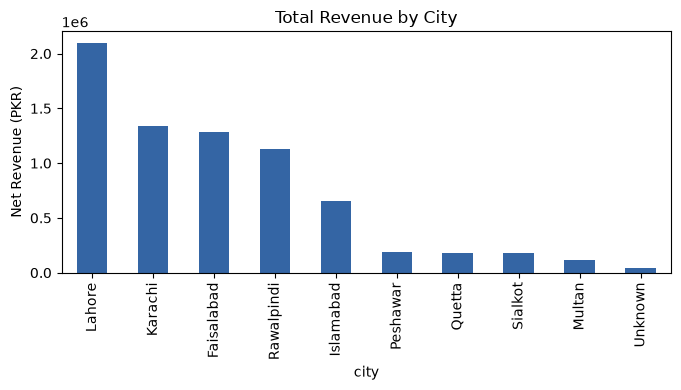

In [118]:
fig, ax = plt.subplots(figsize=(7,4))
sales_by_city.plot(kind='bar', ax=ax, color='#3465a4')
ax.set_title('Total Revenue by City'); ax.set_ylabel('Net Revenue (PKR)')
plt.tight_layout(); 
plt.show()

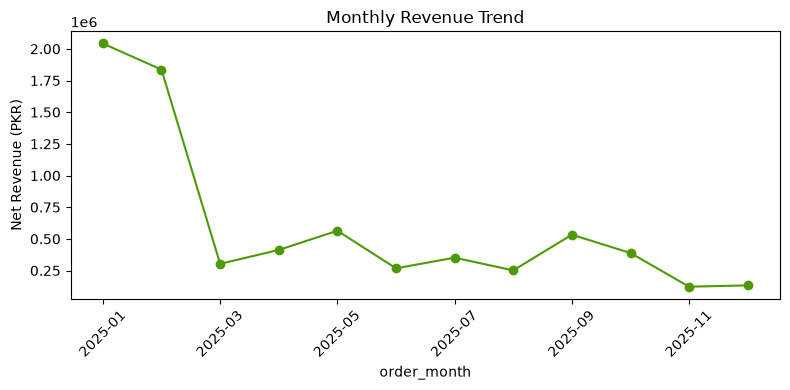

In [119]:
fig, ax = plt.subplots(figsize=(8,4))
monthly_revenue.plot(kind='line', marker='o', ax=ax, color='#4e9a06')
ax.set_title('Monthly Revenue Trend'); ax.set_ylabel('Net Revenue (PKR)')
plt.xticks(rotation=45); plt.tight_layout(); 
plt.show()

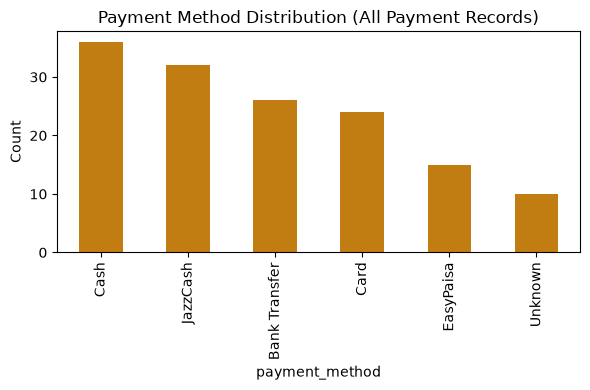

In [120]:
fig, ax = plt.subplots(figsize=(6,4))
payments['payment_method'].value_counts().plot(kind='bar', ax=ax, color='#c17d11')
ax.set_title('Payment Method Distribution (All Payment Records)'); 
ax.set_ylabel('Count')
plt.tight_layout();
plt.show()

## Conclusion
The five raw RetailHub datasets contained widespread missing values, duplicate rows,
inconsistent text formatting, and invalid negative/zero/sentinel values across almost
every column. After cleaning, standardizing, and merging them into a single sales table,
we exported the result to CSV/Excel/JSON, loaded it into `retailhub.db`, and answered all
required SQL and business-analysis questions. See `business_report.pdf` for the
executive summary of findings.